,data_num,ops_num,load_hashmap_time,load_hj_time,ops_hashmap_time,ops_hj_time
0,100,100,22.403333,451.460000,168.500000,604.696667
1,100,500,16.610000,309.193333,709.293333,2670.000000
2,100,1000,16.136667,243.503333,1426.666667,5693.333333
3,500,100,81.530000,346.973333,143.346667,670.986667
4,500,500,84.780000,381.643333,827.306667,3486.666667
5,500,1000,77.643333,334.530000,1403.333333,7153.333333
6,1000,100,149.696667,574.470000,158.873333,921.026667
7,1000,500,157.613333,536.166667,705.830000,4583.333333
8,1000,1000,150.610000,560.250000,1480.000000,9370.000000


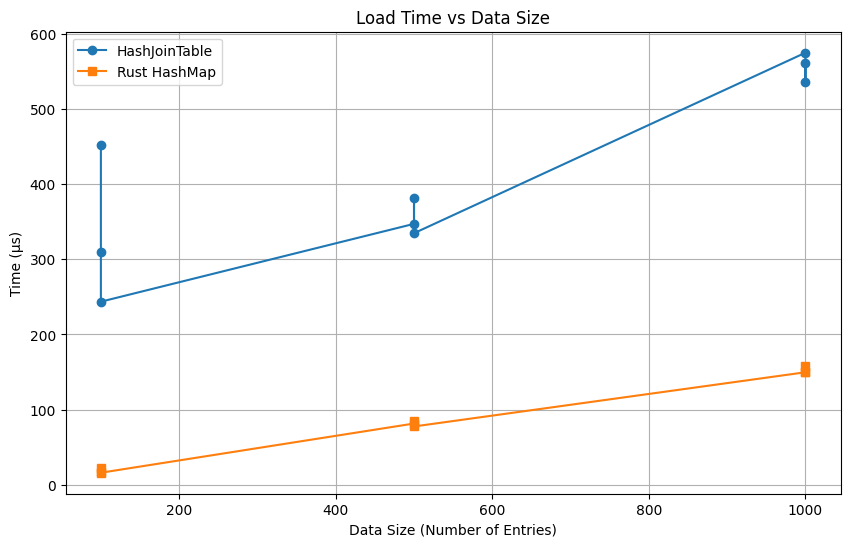

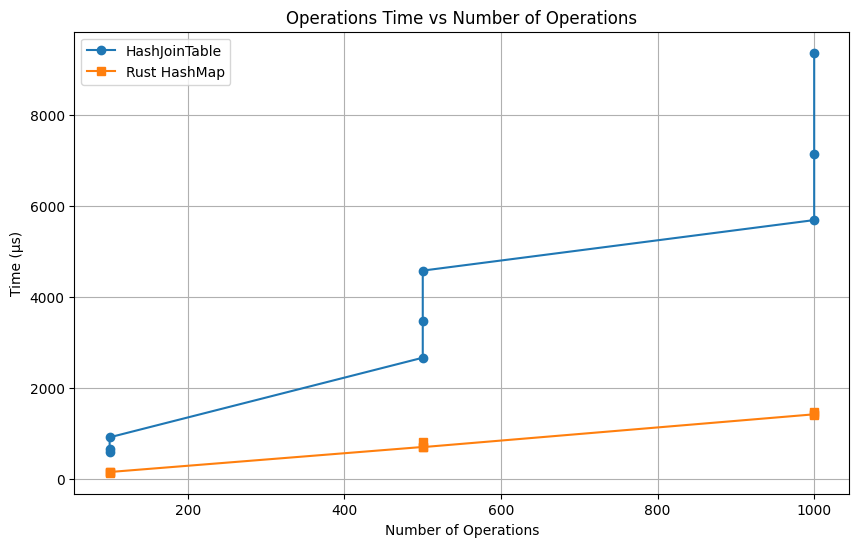

In [ ]:
# Hash Join Benchmark Notebook

# 1. Import Necessary Libraries
import os
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from IPython.display import display, clear_output

# 2. Define Paths
# Define the current directory as the script directory
SCRIPT_DIR = os.path.abspath('.')
print(f"Script directory: {SCRIPT_DIR}")

# If your Rust project is in the same directory, PROJECT_ROOT is the same as SCRIPT_DIR
PROJECT_ROOT = SCRIPT_DIR
print(f"Project root directory: {PROJECT_ROOT}")

# 3. Define Functions

# 3.1 Function to Generate Data
def generate_data(data_params):
    """
    Run gen_data.py with specified parameters.
    """
    gen_data_script = os.path.join(SCRIPT_DIR, 'gen_data.py')
    cmd = ['python3', gen_data_script] + data_params.split()
    print(f"Running gen_data.py with parameters: {data_params}")
    subprocess.run(cmd, check=True)

# 3.2 Function to Generate Transactions
def generate_transactions(txs_params):
    """
    Run gen_txs.py with specified parameters.
    """
    gen_txs_script = os.path.join(SCRIPT_DIR, 'gen_txs.py')
    cmd = ['python3', gen_txs_script] + txs_params.split()
    print(f"Running gen_txs.py with parameters: {txs_params}")
    subprocess.run(cmd, check=True)

# 3.3 Function to Generate Data After Transactions
def generate_data_after_txs():
    """
    Run gen_data_after_txs.py to generate recent and history data after transactions and operations.
    """
    gen_data_after_txs_script = os.path.join(SCRIPT_DIR, 'gen_data_after_txs.py')
    cmd = [
        'python3', gen_data_after_txs_script,
        '--data_file', os.path.join(SCRIPT_DIR, 'data.csv'),
        '--txs_file', os.path.join(SCRIPT_DIR, 'txs.csv'),
        '--ops_file', os.path.join(SCRIPT_DIR, 'ops.csv'),
        '--recent_data_after_txs_file', os.path.join(SCRIPT_DIR, 'recent_data_after_txs.csv'),
        '--history_data_after_txs_file', os.path.join(SCRIPT_DIR, 'history_data_after_txs.csv'),
        '--recent_data_after_ops_file', os.path.join(SCRIPT_DIR, 'recent_data_after_ops.csv'),
        '--history_data_after_ops_file', os.path.join(SCRIPT_DIR, 'history_data_after_ops.csv'),
    ]
    print("Running gen_data_after_txs.py...")
    subprocess.run(cmd, check=True)

# 3.4 Function to Run Benchmark and Capture Output
def run_benchmark():
    """
    Build and run the benchmark, capturing the output.
    """
    # Change to the project root directory
    os.chdir(PROJECT_ROOT)
    
    # Build the Rust project
    print("Building the Rust project...")
    subprocess.run(['cargo', 'build', '--release'], check=True)
    
    # Define paths to data files
    data_csv = os.path.join(SCRIPT_DIR, 'data.csv')
    ops_csv = os.path.join(SCRIPT_DIR, 'ops.csv')
    recent_data_csv = os.path.join(SCRIPT_DIR, 'recent_data_after_ops.csv')
    history_data_csv = os.path.join(SCRIPT_DIR, 'history_data_after_ops.csv')
    
    # Run the benchmark and capture the output
    print("Running the Rust benchmark...")
    cmd = [
        'cargo', 'run', '--release', '--bin', 'hash_join_bench', '--',
        data_csv, ops_csv, recent_data_csv, history_data_csv
    ]
    result = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    output = result.stdout
    print(output)
    return output

# 3.5 Function to Parse Benchmark Output
def parse_benchmark_output(output):
    """
    Parse the benchmark output and extract performance metrics.
    """
    metrics = {}
    # Use regular expressions to extract timing information
    load_hashmap_match = re.search(r"Loaded (\d+) entries into Rust HashMap in ([\d.]+)(\w+)", output)
    load_hj_match = re.search(r"Loaded (\d+) entries into HashJoinTable in ([\d.]+)(\w+)", output)
    ops_hashmap_match = re.search(r"Rust HashMap: Executed (\d+) operations in ([\d.]+)(\w+)", output)
    ops_hj_match = re.search(r"HashJoinTable: Executed (\d+) operations in ([\d.]+)(\w+)", output)
    
    if load_hashmap_match:
        metrics['data_num'] = int(load_hashmap_match.group(1))
        metrics['load_hashmap_time'] = convert_to_microseconds(float(load_hashmap_match.group(2)), load_hashmap_match.group(3))
    if load_hj_match:
        metrics['load_hj_time'] = convert_to_microseconds(float(load_hj_match.group(2)), load_hj_match.group(3))
    if ops_hashmap_match:
        metrics['ops_num'] = int(ops_hashmap_match.group(1))
        metrics['ops_hashmap_time'] = convert_to_microseconds(float(ops_hashmap_match.group(2)), ops_hashmap_match.group(3))
    if ops_hj_match:
        metrics['ops_hj_time'] = convert_to_microseconds(float(ops_hj_match.group(2)), ops_hj_match.group(3))
    
    return metrics

def convert_to_microseconds(value, unit):
    """
    Convert time value to microseconds based on the unit.
    """
    unit = unit.strip()
    if unit == 's':
        return value * 1e6
    elif unit == 'ms':
        return value * 1e3
    elif unit == 'µs' or unit == 'us':
        return value
    elif unit == 'ns':
        return value / 1e3
    else:
        return value  # Default to microseconds if unit is unrecognized

# 4. Define Parameter Ranges and Run Benchmarks

import itertools

results = []

# Define ranges for data_num and ops_num
# data_nums = [1000, 5000, 10000]
# ops_nums = [1000, 5000, 10000]
data_nums = [100]
ops_nums = [100, 500, 1000]

# Loop over combinations of data_num and ops_num
for data_num, ops_num in itertools.product(data_nums, ops_nums):
    # Update parameters for data generation and transactions
    data_params = f"-n {data_num} -k 8 -p 8 -vmin 32 -vmax 64 -s 5"
    txs_params = f"-n {ops_num} -minc 8 -maxc 12 -ro 0.0 -i 0.1 -u 0.3 -d 0.1 -g 0.5"
    
    print(f"\nRunning benchmark with data_num={data_num}, ops_num={ops_num}")
    
    # Generate data
    generate_data(data_params)
    
    # Generate transactions
    generate_transactions(txs_params)
    
    # Generate data after transactions
    generate_data_after_txs()
    
    # Run the benchmark multiple times and collect results
    num_runs = 10  # Adjust the number of runs for averaging
    metrics_list = []
    for run in range(num_runs):
        print(f"Run {run+1}/{num_runs}")
        output = run_benchmark()
        metrics = parse_benchmark_output(output)
        metrics_list.append(metrics)
    
    # Compute averages
    avg_metrics = {
        'data_num': data_num,
        'ops_num': ops_num,
        'load_hashmap_time': np.mean([m['load_hashmap_time'] for m in metrics_list]),
        'load_hj_time': np.mean([m['load_hj_time'] for m in metrics_list]),
        'ops_hashmap_time': np.mean([m['ops_hashmap_time'] for m in metrics_list]),
        'ops_hj_time': np.mean([m['ops_hj_time'] for m in metrics_list]),
    }
    results.append(avg_metrics)
    
    # Clear the output to keep the notebook clean
    clear_output(wait=True)

# 5. Create a DataFrame from Results
df = pd.DataFrame(results)

# 6. Display the DataFrame
display(df)

# 7. Plot the Results

# 7.1 Function to Plot Metrics
def plot_metric(df, x_param, metric_hj, metric_hashmap, title, xlabel):
    plt.figure(figsize=(10, 6))
    
    plt.plot(df[x_param], df[metric_hj], marker='o', label='HashJoinTable')
    plt.plot(df[x_param], df[metric_hashmap], marker='s', label='Rust HashMap')
    
    plt.xlabel(xlabel)
    plt.ylabel('Time (µs)')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# 7.2 Plot Load Times vs Data Size
plot_metric(
    df.sort_values('data_num'),
    'data_num',
    'load_hj_time',
    'load_hashmap_time',
    'Load Time vs Data Size',
    'Data Size (Number of Entries)'
)

# 7.3 Plot Operation Times vs Ops Size
plot_metric(
    df.sort_values('ops_num'),
    'ops_num',
    'ops_hj_time',
    'ops_hashmap_time',
    'Operations Time vs Number of Operations',
    'Number of Operations'
)

# 8. Save Results to CSV (Optional)
# df.to_csv('benchmark_results.csv', index=False)

In [20]:
import os
import subprocess
import glob
import pandas as pd
import matplotlib.pyplot as plt
import re

# Number of runs per workload
n = 3

# Clean up old workload CSV files
workload_dir = './workload'
for f in glob.glob(os.path.join(workload_dir, '*.csv')):
    os.remove(f)

csv_dir = './csv'
for f in glob.glob(os.path.join(csv_dir, '*.csv')):
    os.remove(f)

print("Deleted existing workload CSV files.")

Deleted existing workload CSV files.


In [4]:
# Run gen_workloads.py
print("Generating workloads...")
subprocess.run(['python3', './gen_py/gen_workloads.py'], check=True)
print("Workloads generated.")

Generating workloads...
Generated 1000 transactions in workload/w1_txs.csv
Generated mixed operations in workload/w1_ops.csv
Generated 100 transactions in workload/w2_txs.csv
Generated mixed operations in workload/w2_ops.csv
Workloads generated.


Deleted existing workload CSV files.
Generating workloads...
Generated 1000 transactions in workload/insert_only_txs.csv
Generated mixed operations in workload/insert_only_ops.csv
Generated 1000 transactions in workload/update_only_txs.csv
Generated mixed operations in workload/update_only_ops.csv
Generated 1000 transactions in workload/read50_insert_50_txs.csv
Generated mixed operations in workload/read50_insert_50_ops.csv
Generated 1000 transactions in workload/read_only_txs.csv
Generated mixed operations in workload/read_only_ops.csv
Workloads generated.
Running benchmark for workload insert_only, run 1...
Running benchmark for workload insert_only, run 2...
Running benchmark for workload insert_only, run 3...
Running benchmark for workload insert_only, run 4...
Running benchmark for workload insert_only, run 5...
Running benchmark for workload insert_only, run 6...
Running benchmark for workload insert_only, run 7...
Running benchmark for workload insert_only, run 8...
Running benc

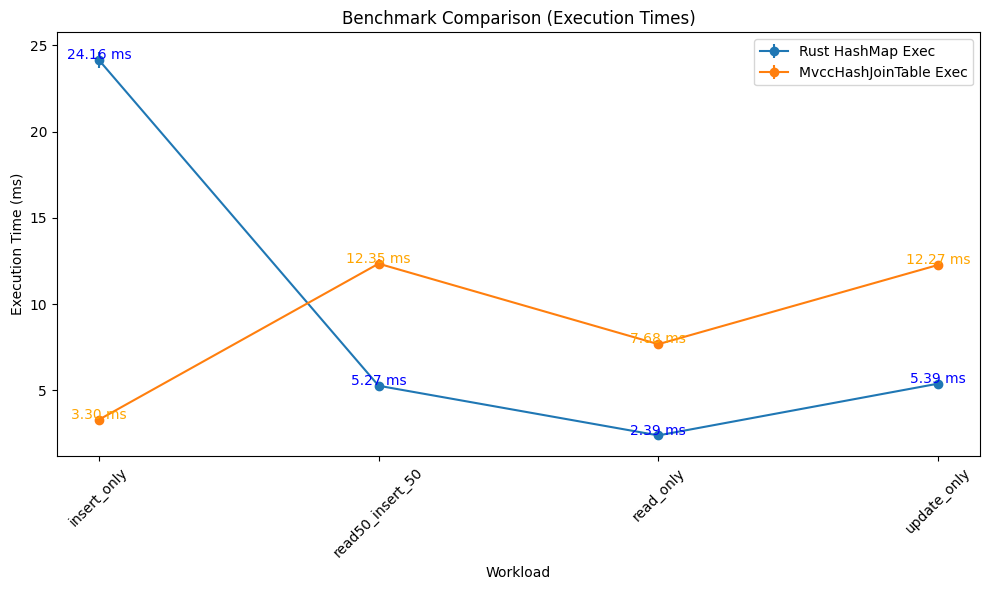

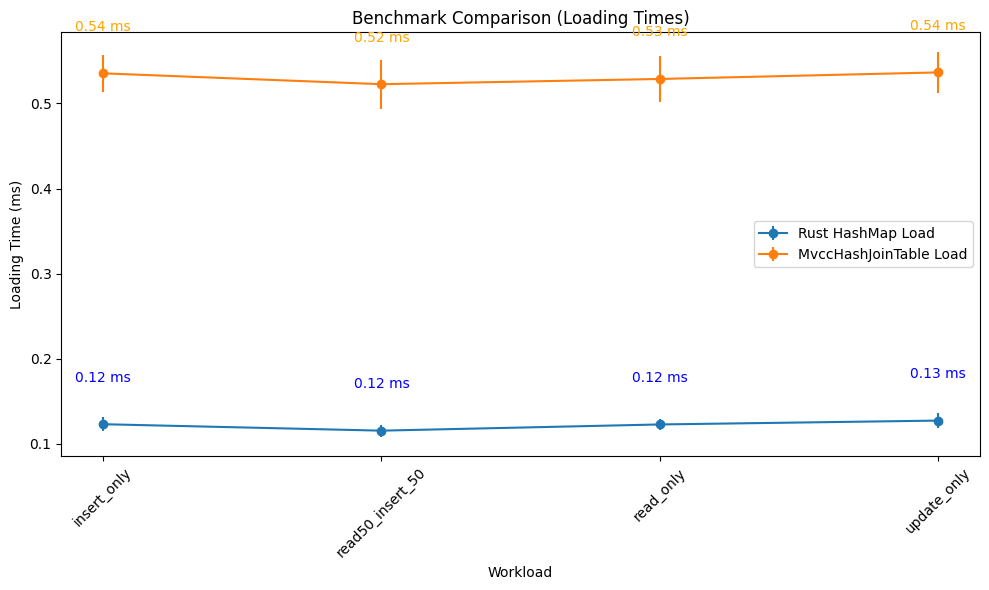

In [ ]:
import os
import subprocess
import glob
import pandas as pd
import matplotlib.pyplot as plt
import re

plt.style.use('custom_plt_sytle.mplstyle')

# Number of runs per workload
n = 2

workload_dir = './workload'
csv_dir = './csv'

# Clean up old workload CSV files
for f in glob.glob(os.path.join(workload_dir, '*.csv')):
    os.remove(f)

# Clean up old benchmark CSV files
for f in glob.glob(os.path.join(csv_dir, '*.csv')):
    os.remove(f)

print("Deleted existing CSV files.")

# Generate workloads
print("Generating workloads...")
subprocess.run(['python3', './gen_py/gen_workloads.py'], check=True)
print("Workloads generated.")

# Paths to binary and CSV files
binary = '../../target/release/hash_join_bench'
data_file = 'csv/data.csv'
recent_data_file = 'csv/recent_data_after_ops.csv'
history_data_file = 'csv/history_data_after_ops.csv'
scan_ops_file = 'csv/scan_ops.csv'

# Find all workload ops files (no longer assume w* prefix)
ops_files = glob.glob(os.path.join(workload_dir, '*_ops.csv'))
ops_files.sort()

results = []  # will hold dicts of {workload, run, rust_load_ns, hj_load_ns, rust_exec_ns, hj_exec_ns}

for ops_path in ops_files:
    workload_name = os.path.splitext(os.path.basename(ops_path))[0].replace('_ops','')

    for run_id in range(1, n+1):
        print(f"Running benchmark for workload {workload_name}, run {run_id}...")
        cmd = [
            binary,
            '-df', data_file,
            '-of', ops_path,
            '-rdf', recent_data_file,
            '-hdf', history_data_file,
            '-sof', scan_ops_file
        ]

        completed = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True, check=True)
        output = completed.stdout

        # Parse times
        rust_load_time_ns = None
        hj_load_time_ns = None
        rust_time_ns = None
        hj_time_ns = None

        for line in output.splitlines():
            if line.startswith("Loaded") and "Rust HashMap" in line:
                m = re.search(r'Loaded \d+ entries into Rust HashMap in (\d+) ns', line)
                if m:
                    rust_load_time_ns = int(m.group(1))
            elif line.startswith("Loaded") and "HashJoinTable" in line:
                m = re.search(r'Loaded \d+ entries into HashJoinTable in (\d+) ns', line)
                if m:
                    hj_load_time_ns = int(m.group(1))
            elif line.startswith("Rust HashMap: Executed"):
                m = re.search(r'Executed \d+ operations in (\d+) ns', line)
                if m:
                    rust_time_ns = int(m.group(1))
            elif line.startswith("HashJoinTable: Executed"):
                m = re.search(r'Executed \d+ operations in (\d+) ns', line)
                if m:
                    hj_time_ns = int(m.group(1))

        if (rust_time_ns is None or hj_time_ns is None or
            rust_load_time_ns is None or hj_load_time_ns is None):
            print("Warning: Could not parse all times from output for this run:")
            print(output)
        else:
            results.append({
                'workload': workload_name,
                'run': run_id,
                'rust_load_ns': rust_load_time_ns,
                'hj_load_ns': hj_load_time_ns,
                'rust_exec_ns': rust_time_ns,
                'hj_exec_ns': hj_time_ns
            })

print("Benchmarking completed.")

df = pd.DataFrame(results)

if df.empty:
    print("No results were parsed. Check the output format or regex patterns.")
    print("ops_files found:", ops_files)
    # Print a sample workload run output for debugging if needed
else:
    # Compute means and std dev for each workload (both load and exec times)
    stats = df.groupby('workload').agg({
        'rust_load_ns': ['mean', 'std'],
        'hj_load_ns': ['mean', 'std'],
        'rust_exec_ns': ['mean', 'std'],
        'hj_exec_ns': ['mean', 'std']
    })

    # Flatten column MultiIndex
    stats.columns = [
        'rust_load_mean', 'rust_load_std',
        'hj_load_mean', 'hj_load_std',
        'rust_exec_mean', 'rust_exec_std',
        'hj_exec_mean', 'hj_exec_std'
    ]
    stats = stats.reset_index()

    # Sort workloads alphabetically since they don't have numeric IDs
    stats = stats.sort_values('workload')

    # Convert to ms for readability
    stats['rust_load_mean_ms'] = stats['rust_load_mean'] / 1_000_000
    stats['rust_exec_mean_ms'] = stats['rust_exec_mean'] / 1_000_000
    stats['hj_load_mean_ms'] = stats['hj_load_mean'] / 1_000_000
    stats['hj_exec_mean_ms'] = stats['hj_exec_mean'] / 1_000_000

    # Print the exact numbers before plotting
    print("Averaged Results:")
    for i, row in stats.iterrows():
        print(f"Workload: {row['workload']}")
        print(f"  Rust HashMap: load={row['rust_load_mean_ms']:.2f} ms, exec={row['rust_exec_mean_ms']:.2f} ms")
        print(f"  MvccHashJoinTable: load={row['hj_load_mean_ms']:.2f} ms, exec={row['hj_exec_mean_ms']:.2f} ms")

    # Plot Execution Times Comparison
    plt.figure(figsize=(10,6))
    X = range(len(stats))
    plt.errorbar(X, stats['rust_exec_mean_ms'], yerr=stats['rust_exec_std']/1_000_000, fmt='o-', label='Rust HashMap Exec')
    plt.errorbar(X, stats['hj_exec_mean_ms'], yerr=stats['hj_exec_std']/1_000_000, fmt='o-', label='MvccHashJoinTable Exec')

    plt.xticks(X, stats['workload'], rotation=45)
    plt.xlabel('Workload')
    plt.ylabel('Execution Time (ms)')
    plt.title('Benchmark Comparison (Execution Times)')
    plt.legend()

    # Annotate points with exact values
    for i, x_val in enumerate(X):
        plt.text(x_val, stats['rust_exec_mean_ms'][i] + 0.05, f"{stats['rust_exec_mean_ms'][i]:.2f} ms", ha='center', color='blue')
        plt.text(x_val, stats['hj_exec_mean_ms'][i] + 0.05, f"{stats['hj_exec_mean_ms'][i]:.2f} ms", ha='center', color='orange')

    plt.tight_layout()
    plt.show()

    # Plot Loading Times Comparison
    plt.figure(figsize=(10,6))
    X = range(len(stats))
    plt.errorbar(X, stats['rust_load_mean_ms'], yerr=stats['rust_load_std']/1_000_000, fmt='o-', label='Rust HashMap Load')
    plt.errorbar(X, stats['hj_load_mean_ms'], yerr=stats['hj_load_std']/1_000_000, fmt='o-', label='MvccHashJoinTable Load')

    plt.xticks(X, stats['workload'], rotation=45)
    plt.xlabel('Workload')
    plt.ylabel('Loading Time (ms)')
    plt.title('Benchmark Comparison (Loading Times)')
    plt.legend()

    # Annotate points with exact values
    for i, x_val in enumerate(X):
        plt.text(x_val, stats['rust_load_mean_ms'][i] + 0.05, f"{stats['rust_load_mean_ms'][i]:.2f} ms", ha='center', color='blue')
        plt.text(x_val, stats['hj_load_mean_ms'][i] + 0.05, f"{stats['hj_load_mean_ms'][i]:.2f} ms", ha='center', color='orange')

    plt.tight_layout()
    plt.show()


Deleted existing CSV files.
Building hash_join_bench with cargo build --release...


 --> src/access_method/fbt/foster_btree.rs:7:18
  |
7 |         atomic::{AtomicUsize, Ordering},
  |                  ^^^^^^^^^^^
  |
  = note: `#[warn(unused_imports)]` on by default

 --> src/mvcc_index/hash_join/mvcc_hash_join.rs:2:5
  |
2 |     access_method::fbt::FosterBtreeRangeScanner,
  |     ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
3 |     bp::{ContainerKey, FrameReadGuard, MemPool, MemPoolStatus, PageFrameKey},
4 |     log_debug, log_trace, log_warn,
  |     ^^^^^^^^^  ^^^^^^^^^

  --> src/mvcc_index/hash_join/mvcc_hash_join.rs:10:44
   |
10 |     collections::{hash_map::DefaultHasher, HashMap, HashSet},
   |                                            ^^^^^^^
11 |     error::Error,
   |     ^^^^^^^^^^^^
...
16 |     vec::IntoIter,
   |     ^^^^^^^^^^^^^

  --> src/mvcc_index/hash_join/mvcc_hash_join.rs:24:22
   |
24 |     Timestamp, TxId, TxInfo,
   |                      ^^^^^^

  --> src/mvcc_index/hash_join/mvcc_hash_join.rs:27:5
   |
27 | use rand::seq::index;
   |    

Build completed.
Running gen_data.py...
data.csv generated.
Generating workloads...
Generated 1000 transactions in csv/insert_only_txs.csv
Generated mixed operations in csv/insert_only_ops.csv
Generated 1000 transactions in csv/update_only_txs.csv
Generated mixed operations in csv/update_only_ops.csv
Generated 1000 transactions in csv/read50_insert_50_txs.csv
Generated mixed operations in csv/read50_insert_50_ops.csv
Generated 1000 transactions in csv/read_only_txs.csv
Generated mixed operations in csv/read_only_ops.csv
Workloads generated.
Generating data after ops for each workload (via gen_workloads_results.py)...
Processing workload insert_only with gen_data_after_txs.py...

Processing transactions (txs.csv)...
Generated recent data in csv/insert_only_recent_data_after_txs.csv
Generated history data in csv/insert_only_history_data_after_txs.csv

Processing operations (ops.csv)...
Generated recent data in csv/insert_only_recent_data_after_ops.csv
Generated history data in csv/insert

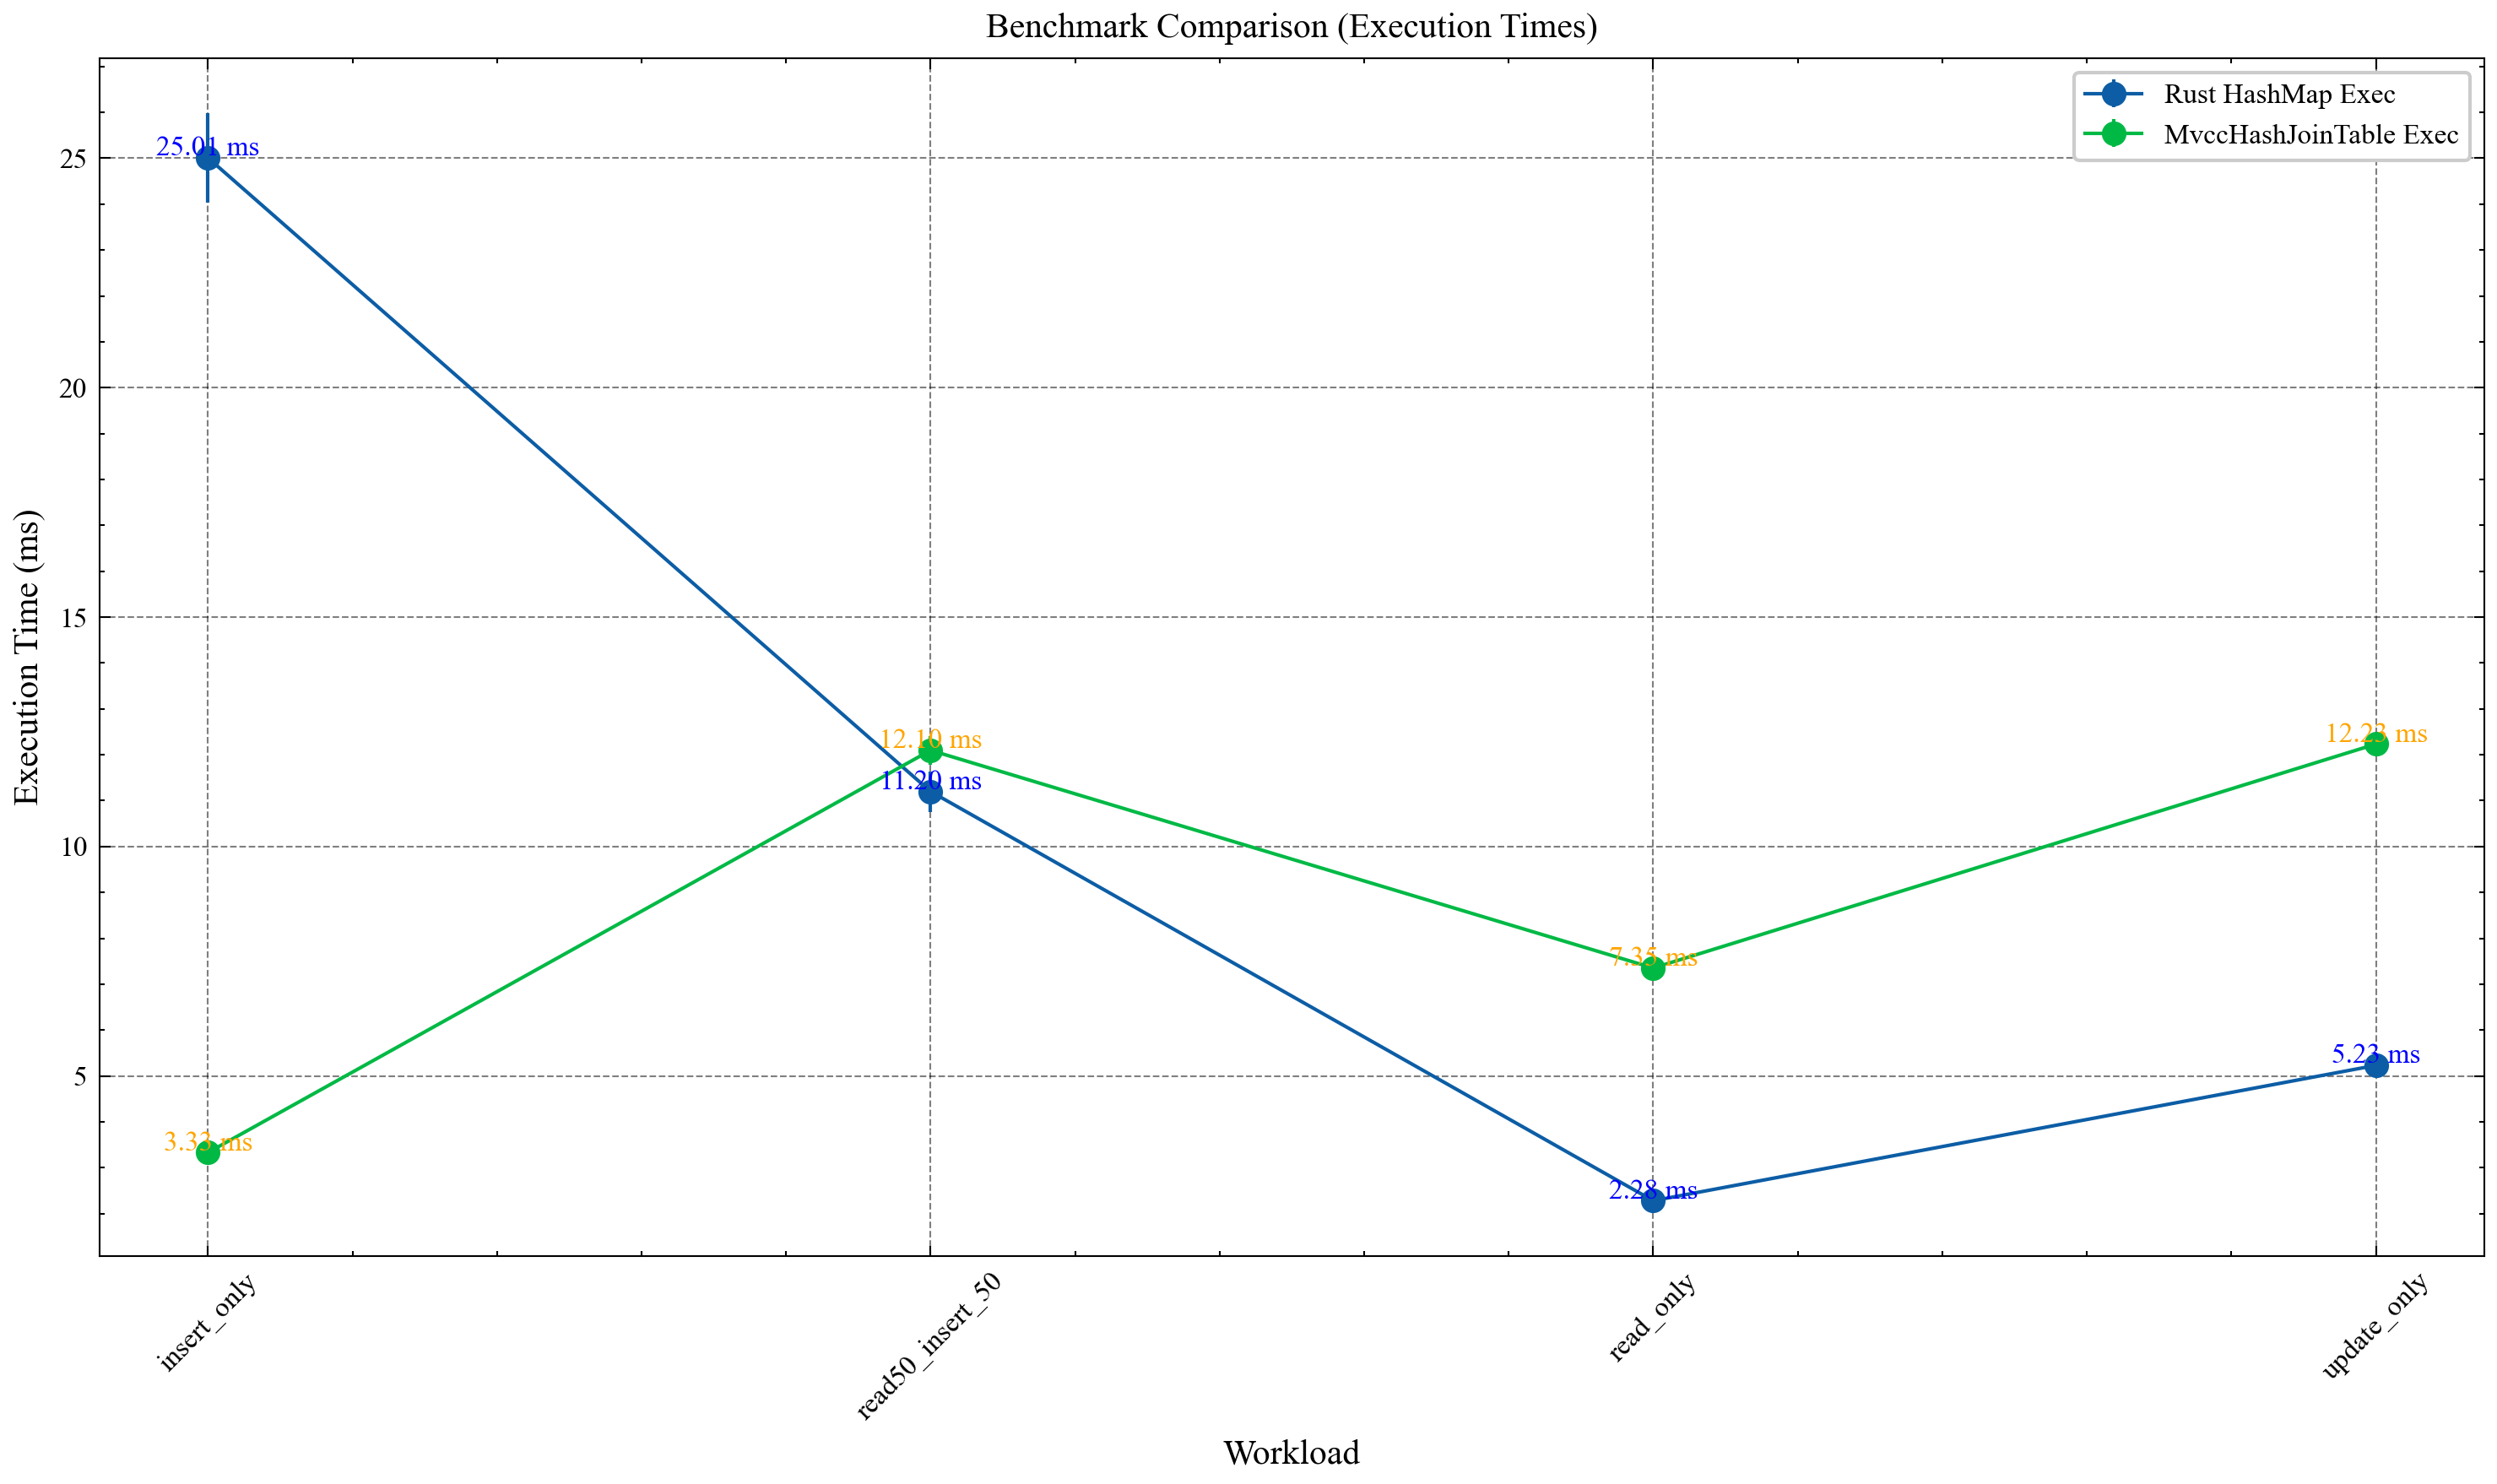

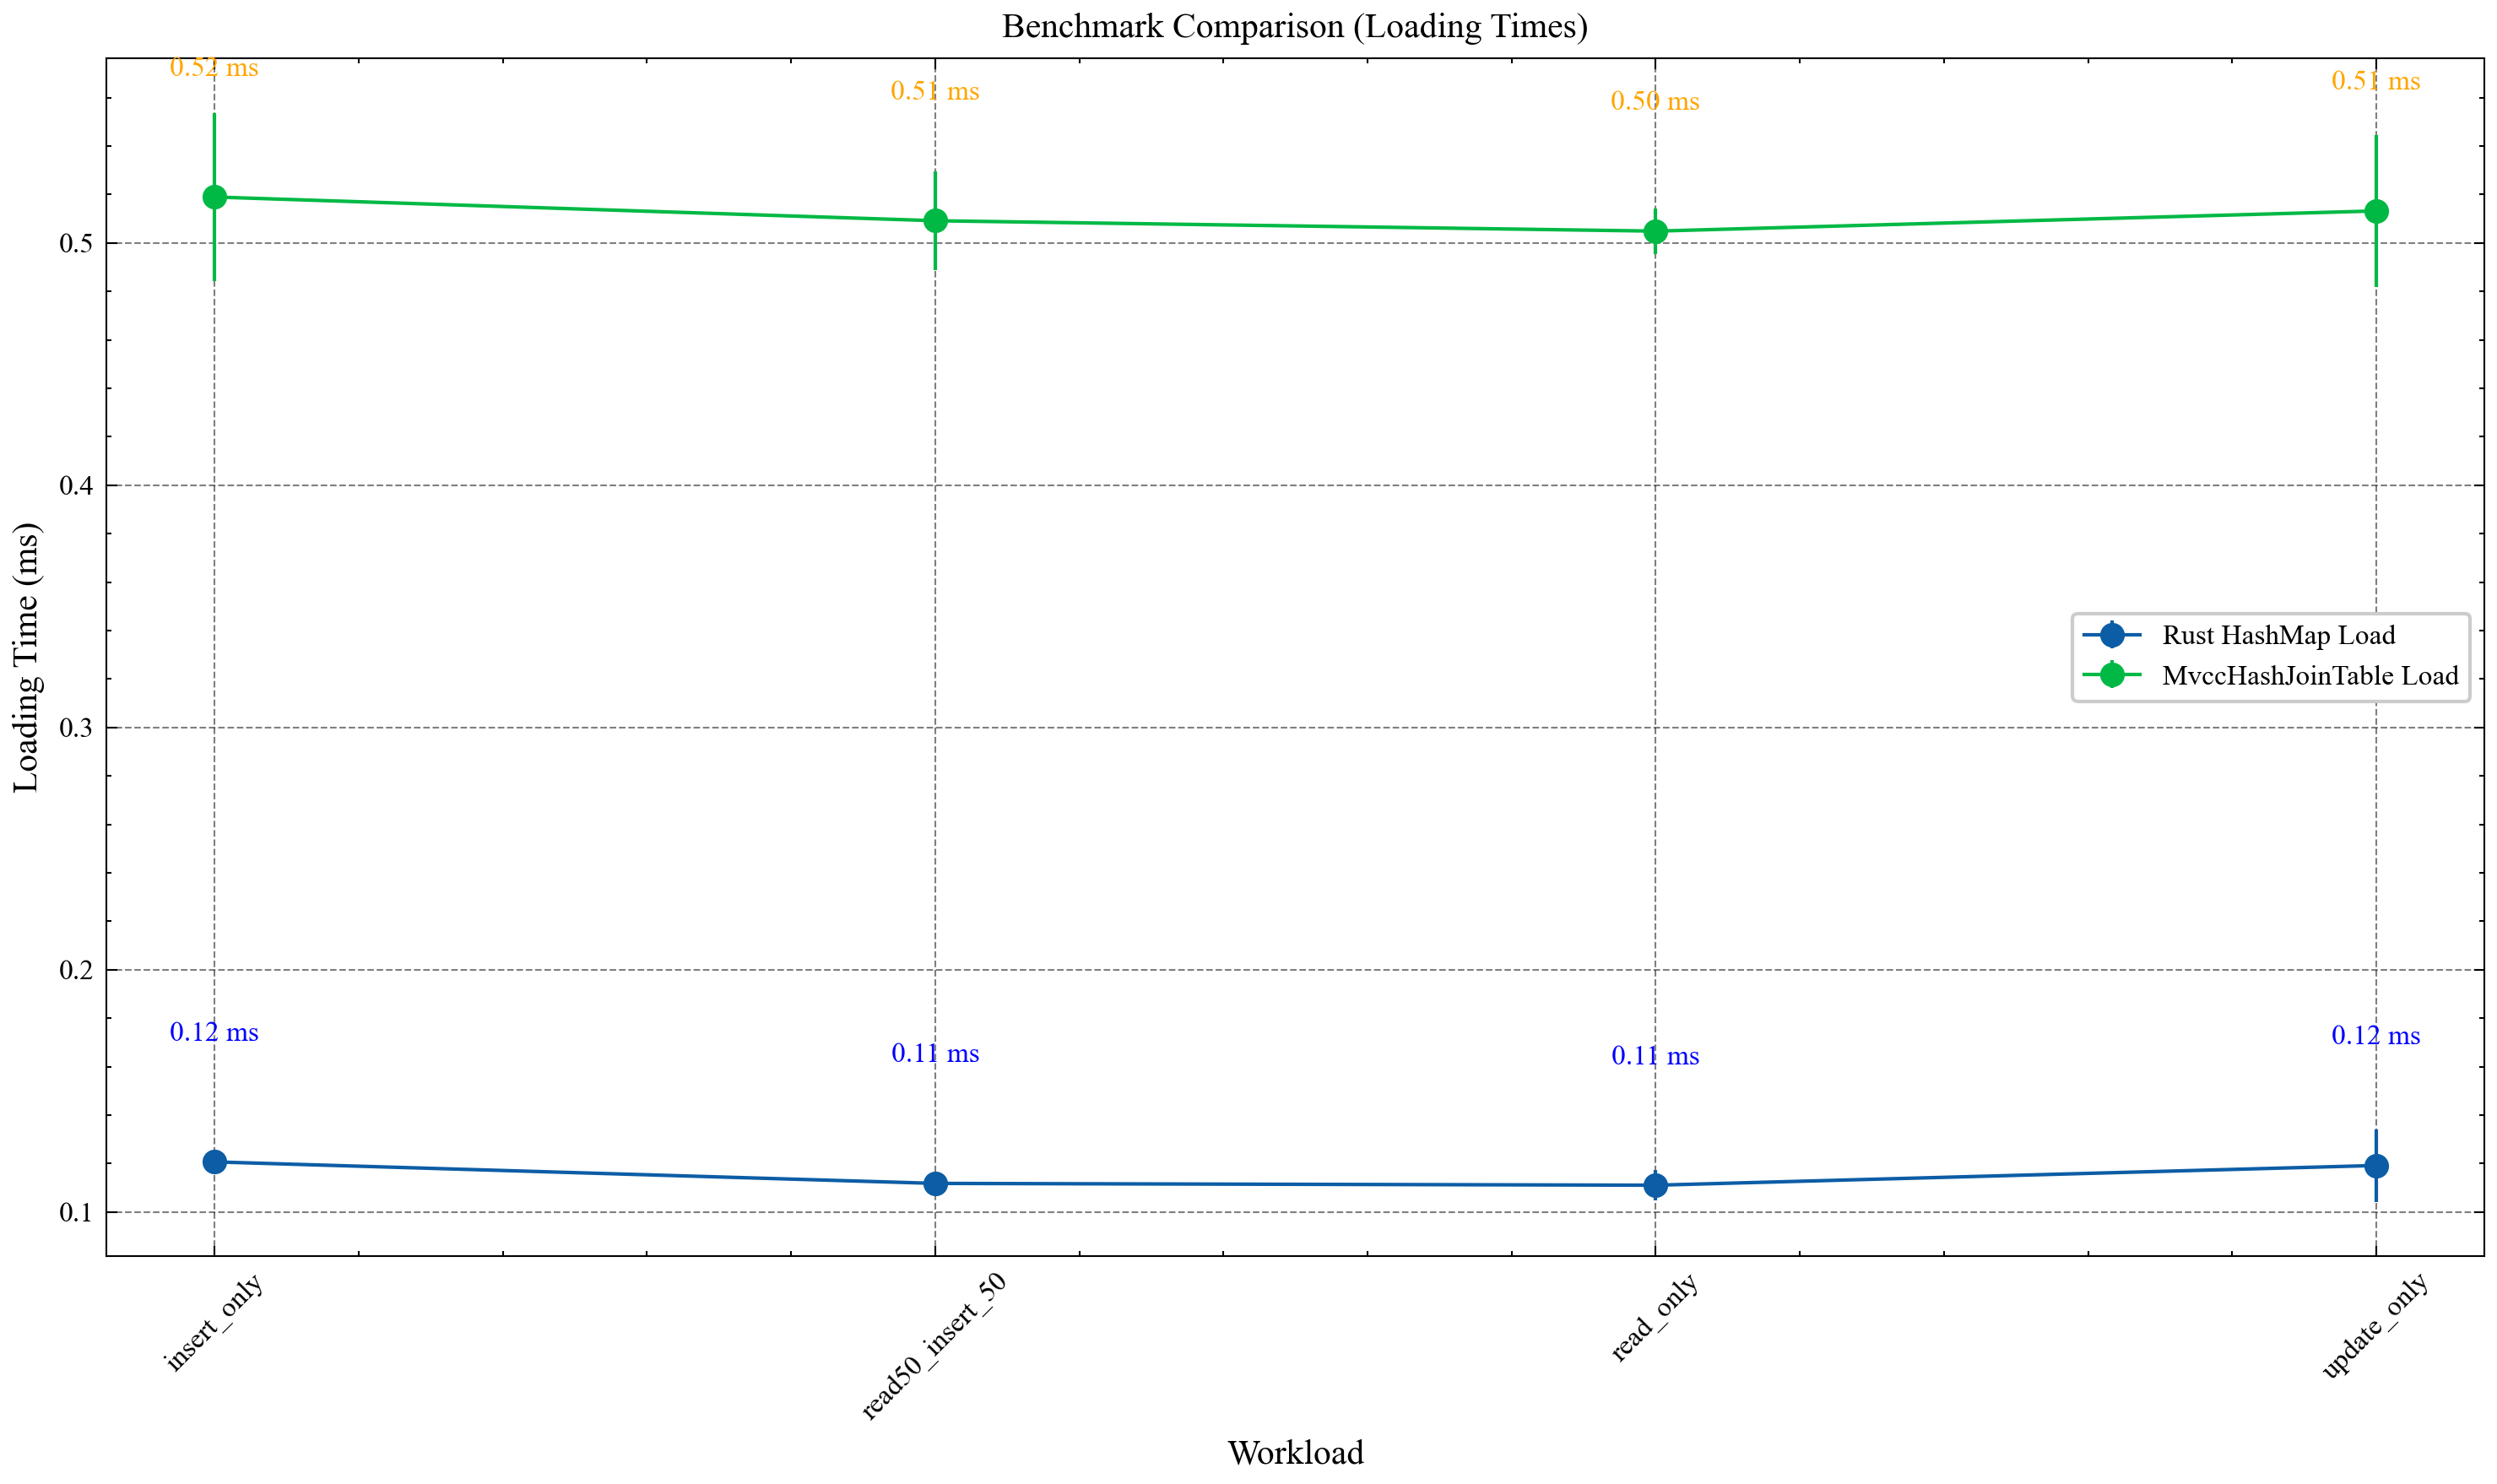

In [24]:
import os
import subprocess
import glob
import pandas as pd
import matplotlib.pyplot as plt
import re
import filecmp

# Use the custom style
plt.style.use('custom_plt_sytle.mplstyle')

# Number of runs per workload
n = 2

workload_dir = './workload'
csv_dir = './csv'

# Clean up old CSV files in workload and csv directories
for f in glob.glob(os.path.join(workload_dir, '*.csv')):
    os.remove(f)
for f in glob.glob(os.path.join(csv_dir, '*.csv')):
    os.remove(f)

print("Deleted existing CSV files.")

# Build the binary to ensure it's up-to-date
print("Building hash_join_bench with cargo build --release...")
subprocess.run(['cargo', 'build', '--release'], check=True)
print("Build completed.")

# Run gen_data.py to generate data.csv
print("Running gen_data.py...")
subprocess.run([
    'python3', './gen_py/gen_data.py',
    '-o', os.path.join(csv_dir, 'data.csv'),
    '-n', '1000', '-k', '8', '-p', '8', '-vmin', '32', '-vmax', '64', '-s', '5'
], check=True)
print("data.csv generated.")

# Generate workloads (txs and ops files)
print("Generating workloads...")
subprocess.run(['python3', './gen_py/gen_workloads.py'], check=True)
print("Workloads generated.")

# Generate data after ops for each workload (producing workload-specific *_recent_data_after_ops.csv and *_history_data_after_ops.csv)
print("Generating data after ops for each workload (via gen_workloads_results.py)...")
subprocess.run(['python3', './gen_py/gen_workloads_results.py'], check=True)
print("Workloads results generated.")

binary = '../../target/release/hash_join_bench'
data_file = os.path.join(csv_dir, 'data.csv')
scan_ops_file = os.path.join(csv_dir, 'scan_ops.csv')

# Find all workload ops files in csv directory
ops_files = glob.glob(os.path.join(csv_dir, '*_ops.csv'))
ops_files.sort()

results = []  # will hold dicts of {workload, run, rust_load_ns, hj_load_ns, rust_exec_ns, hj_exec_ns}

for ops_path in ops_files:
    workload_name = os.path.splitext(os.path.basename(ops_path))[0].replace('_ops','')

    # Corresponding recent/history after ops files
    recent_data_after_ops_file = os.path.join(csv_dir, f'{workload_name}_recent_data_after_ops.csv')
    history_data_after_ops_file = os.path.join(csv_dir, f'{workload_name}_history_data_after_ops.csv')

    # Check if they exist
    if not os.path.exists(recent_data_after_ops_file) or not os.path.exists(history_data_after_ops_file):
        print(f"Missing recent/history after ops files for workload {workload_name}, skipping benchmark.")
        continue

    # Run the benchmark multiple times for each workload
    for run_id in range(1, n+1):
        print(f"Running benchmark for workload {workload_name}, run {run_id}...")
        cmd = [
            binary,
            '-df', data_file,
            '-of', ops_path,
            '-rdf', recent_data_after_ops_file,
            '-hdf', history_data_after_ops_file,
            '-sof', scan_ops_file
        ]

        completed = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
        if completed.returncode != 0:
            print(f"Benchmark failed for workload {workload_name}, run {run_id}:")
            print(completed.stderr)
            continue

        output = completed.stdout

        # Parse times
        rust_load_time_ns = None
        hj_load_time_ns = None
        rust_time_ns = None
        hj_time_ns = None

        for line in output.splitlines():
            if line.startswith("Loaded") and "Rust HashMap" in line:
                m = re.search(r'Loaded \d+ entries into Rust HashMap in (\d+) ns', line)
                if m:
                    rust_load_time_ns = int(m.group(1))
            elif line.startswith("Loaded") and "HashJoinTable" in line:
                m = re.search(r'Loaded \d+ entries into HashJoinTable in (\d+) ns', line)
                if m:
                    hj_load_time_ns = int(m.group(1))
            elif line.startswith("Rust HashMap: Executed"):
                m = re.search(r'Executed \d+ operations in (\d+) ns', line)
                if m:
                    rust_time_ns = int(m.group(1))
            elif line.startswith("HashJoinTable: Executed"):
                m = re.search(r'Executed \d+ operations in (\d+) ns', line)
                if m:
                    hj_time_ns = int(m.group(1))

        if (rust_time_ns is None or hj_time_ns is None or
            rust_load_time_ns is None or hj_load_time_ns is None):
            print("Warning: Could not parse all times from output for this run:")
            print(output)
        else:
            results.append({
                'workload': workload_name,
                'run': run_id,
                'rust_load_ns': rust_load_time_ns,
                'hj_load_ns': hj_load_time_ns,
                'rust_exec_ns': rust_time_ns,
                'hj_exec_ns': hj_time_ns
            })

print("Benchmarking completed.")

df = pd.DataFrame(results)

if df.empty:
    print("No results were parsed. Check the output format or regex patterns.")
else:
    # Compute means and std dev for each workload (both load and exec times)
    stats = df.groupby('workload').agg({
        'rust_load_ns': ['mean', 'std'],
        'hj_load_ns': ['mean', 'std'],
        'rust_exec_ns': ['mean', 'std'],
        'hj_exec_ns': ['mean', 'std']
    })

    # Flatten column MultiIndex
    stats.columns = [
        'rust_load_mean', 'rust_load_std',
        'hj_load_mean', 'hj_load_std',
        'rust_exec_mean', 'rust_exec_std',
        'hj_exec_mean', 'hj_exec_std'
    ]
    stats = stats.reset_index()

    # Sort workloads alphabetically
    stats = stats.sort_values('workload')

    # Convert to ms for readability
    stats['rust_load_mean_ms'] = stats['rust_load_mean'] / 1_000_000
    stats['rust_exec_mean_ms'] = stats['rust_exec_mean'] / 1_000_000
    stats['hj_load_mean_ms'] = stats['hj_load_mean'] / 1_000_000
    stats['hj_exec_mean_ms'] = stats['hj_exec_mean'] / 1_000_000

    # Print exact numbers
    print("Averaged Results:")
    for i, row in stats.iterrows():
        print(f"Workload: {row['workload']}")
        print(f"  Rust HashMap: load={row['rust_load_mean_ms']:.2f} ms, exec={row['rust_exec_mean_ms']:.2f} ms")
        print(f"  MvccHashJoinTable: load={row['hj_load_mean_ms']:.2f} ms, exec={row['hj_exec_mean_ms']:.2f} ms")

    # Plot Execution Times Comparison
    plt.figure(figsize=(10,6))
    X = range(len(stats))
    plt.errorbar(X, stats['rust_exec_mean_ms'], yerr=stats['rust_exec_std']/1_000_000, fmt='o-', label='Rust HashMap Exec')
    plt.errorbar(X, stats['hj_exec_mean_ms'], yerr=stats['hj_exec_std']/1_000_000, fmt='o-', label='MvccHashJoinTable Exec')

    plt.xticks(X, stats['workload'], rotation=45)
    plt.xlabel('Workload')
    plt.ylabel('Execution Time (ms)')
    plt.title('Benchmark Comparison (Execution Times)')
    plt.legend()

    # Annotate points with exact values
    for i, x_val in enumerate(X):
        plt.text(x_val, stats['rust_exec_mean_ms'][i] + 0.05, f"{stats['rust_exec_mean_ms'][i]:.2f} ms", ha='center', color='blue')
        plt.text(x_val, stats['hj_exec_mean_ms'][i] + 0.05, f"{stats['hj_exec_mean_ms'][i]:.2f} ms", ha='center', color='orange')

    plt.tight_layout()
    plt.show()

    # Plot Loading Times Comparison
    plt.figure(figsize=(10,6))
    X = range(len(stats))
    plt.errorbar(X, stats['rust_load_mean_ms'], yerr=stats['rust_load_std']/1_000_000, fmt='o-', label='Rust HashMap Load')
    plt.errorbar(X, stats['hj_load_mean_ms'], yerr=stats['hj_load_std']/1_000_000, fmt='o-', label='MvccHashJoinTable Load')

    plt.xticks(X, stats['workload'], rotation=45)
    plt.xlabel('Workload')
    plt.ylabel('Loading Time (ms)')
    plt.title('Benchmark Comparison (Loading Times)')
    plt.legend()

    # Annotate points with exact values
    for i, x_val in enumerate(X):
        plt.text(x_val, stats['rust_load_mean_ms'][i] + 0.05, f"{stats['rust_load_mean_ms'][i]:.2f} ms", ha='center', color='blue')
        plt.text(x_val, stats['hj_load_mean_ms'][i] + 0.05, f"{stats['hj_load_mean_ms'][i]:.2f} ms", ha='center', color='orange')

    plt.tight_layout()
    plt.show()
